# SpaceX Falcon 9 First Stage Landing Prediction
## Module 5: Exploratory Data Analysis with Data Visualization

**Author:** Pritam Acharya

Visual EDA on the wrangled dataset (`dataset_part_2.csv`) — looking for patterns in how flight number, payload mass, launch site, orbit type, and booster block relate to landing success (`Class`). These patterns motivate the feature engineering and model choice in later modules.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/dataset_part_2.csv")
sns.set_style("whitegrid")
df.head()

Matplotlib is building the font cache; this may take a moment.


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Flight number vs payload mass, by landing outcome
Early flights (low FlightNumber) show mostly failed landings (red); as flight number increases, successful landings (green) become far more common — SpaceX visibly improved its recovery success rate over time.

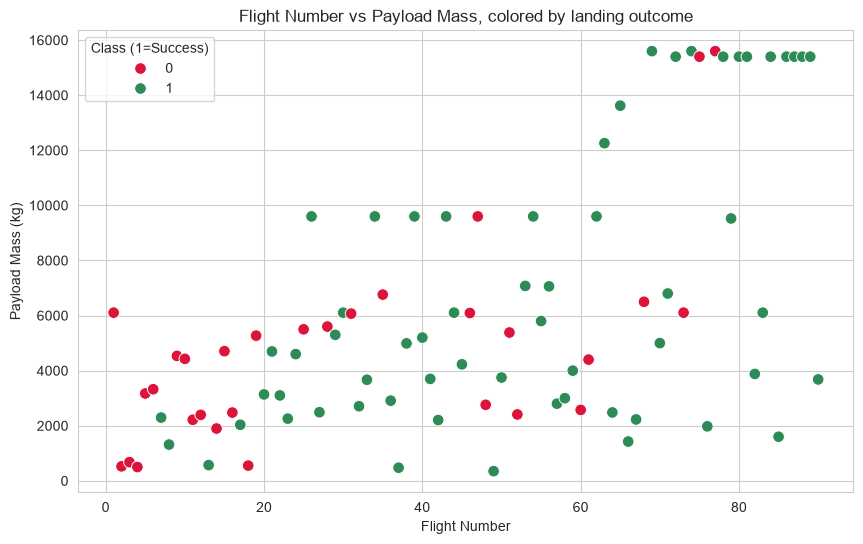

In [2]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="FlightNumber", y="PayloadMass", hue="Class",
                 palette={0:"crimson", 1:"seagreen"}, s=70)
plt.xlabel("Flight Number")
plt.ylabel("Payload Mass (kg)")
plt.title("Flight Number vs Payload Mass, colored by landing outcome")
plt.legend(title="Class (1=Success)")
plt.show()

### Flight number vs launch site, by landing outcome
KSC LC-39A only started hosting launches later in the program (higher flight numbers) and shows an almost entirely successful record — it was brought online after SpaceX had already matured its recovery process.

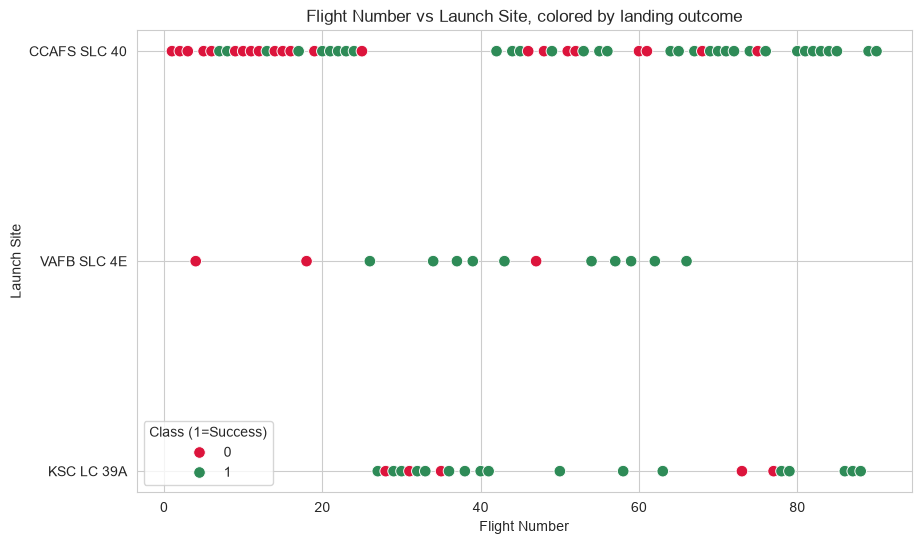

In [3]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="FlightNumber", y="LaunchSite", hue="Class",
                 palette={0:"crimson", 1:"seagreen"}, s=70)
plt.xlabel("Flight Number")
plt.ylabel("Launch Site")
plt.title("Flight Number vs Launch Site, colored by landing outcome")
plt.legend(title="Class (1=Success)")
plt.show()

### Payload mass vs launch site, by landing outcome
VAFB SLC-4E has never launched a payload heavier than ~10,000 kg in this dataset — it's used for polar/sun-synchronous orbits which typically carry lighter payloads than GTO missions from CCAFS/KSC.

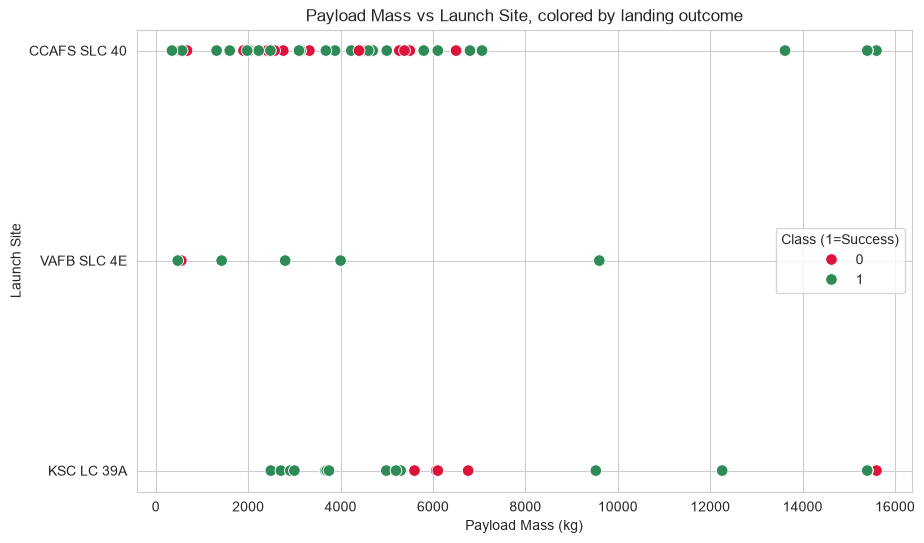

In [4]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="PayloadMass", y="LaunchSite", hue="Class",
                 palette={0:"crimson", 1:"seagreen"}, s=70)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.title("Payload Mass vs Launch Site, colored by landing outcome")
plt.legend(title="Class (1=Success)")
plt.show()

### Landing success rate by orbit type
ES-L1, GEO, HEO, SSO, and VLEO orbits show a 100% success rate in this dataset — though several of these have only 1-3 flights, so that perfect record isn't yet statistically strong. GTO (the most common commercial orbit) sits lower, likely because higher-energy GTO missions are the most demanding on the booster.

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_34520\459838021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orbit_success.index, y=orbit_success.values, palette="viridis")


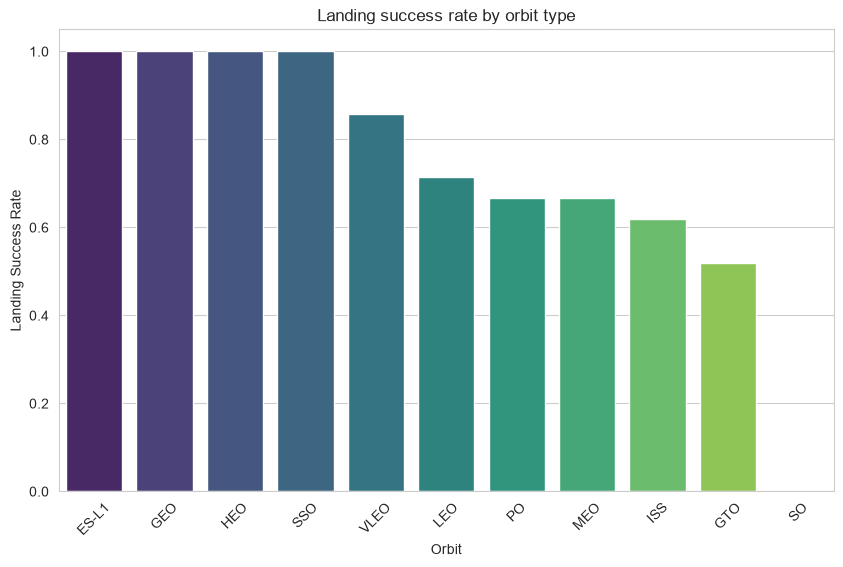

In [5]:
orbit_success = df.groupby("Orbit")["Class"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=orbit_success.index, y=orbit_success.values, palette="viridis")
plt.xlabel("Orbit")
plt.ylabel("Landing Success Rate")
plt.title("Landing success rate by orbit type")
plt.xticks(rotation=45)
plt.show()

### Flight number vs orbit, by landing outcome
VLEO missions (Starlink) are heavily concentrated at high flight numbers — they only began in 2019 — and show a strong success rate, reflecting the booster maturity by that point in the program.

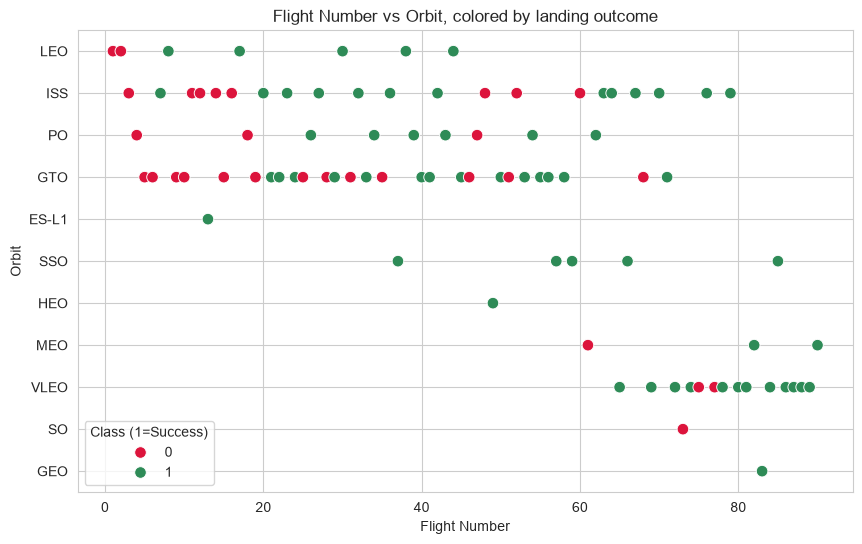

In [6]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="FlightNumber", y="Orbit", hue="Class",
                 palette={0:"crimson", 1:"seagreen"}, s=70)
plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.title("Flight Number vs Orbit, colored by landing outcome")
plt.legend(title="Class (1=Success)")
plt.show()

### Payload mass vs orbit, by landing outcome
Heavy payloads (>10,000 kg) succeed almost exclusively in LEO/VLEO — these are Starlink batches, launched by a well-proven Block 5 booster. Heavy GTO payloads are rarer and show more mixed outcomes, consistent with GTO being a harder recovery profile.

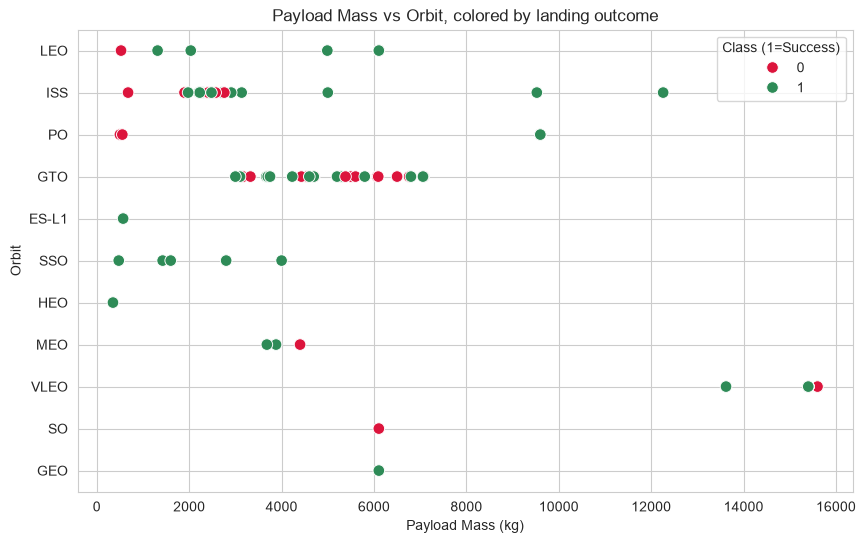

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="PayloadMass", y="Orbit", hue="Class",
                 palette={0:"crimson", 1:"seagreen"}, s=70)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit")
plt.title("Payload Mass vs Orbit, colored by landing outcome")
plt.legend(title="Class (1=Success)")
plt.show()

### Yearly trend in landing success rate
The clearest signal in the whole dataset: success rate is essentially 0% through 2013, rises steadily from 2014, and stabilizes in the 60-90% range from 2017 onward. `Date`/`FlightNumber` will likely be strong predictive features.

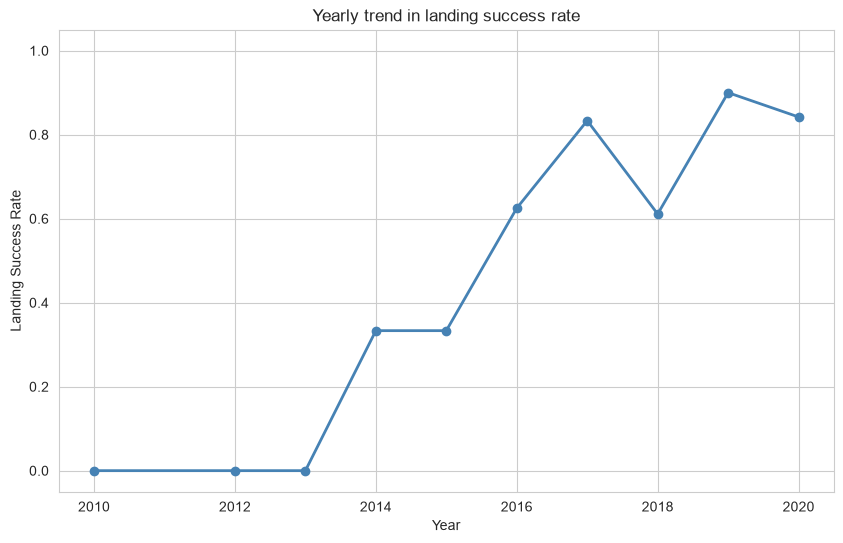

In [8]:
df["Year"] = pd.to_datetime(df["Date"]).dt.year
yearly = df.groupby("Year")["Class"].mean()
plt.figure(figsize=(10,6))
plt.plot(yearly.index, yearly.values, marker="o", linewidth=2, color="steelblue")
plt.xlabel("Year")
plt.ylabel("Landing Success Rate")
plt.title("Yearly trend in landing success rate")
plt.ylim(-0.05, 1.05)
plt.show()

### Feature engineering: one-hot encoding categoricals

For the machine learning models in later modules, we convert categorical columns (`Orbit`, `LaunchSite`, `LandingPad`) into dummy/indicator variables, and cast boolean columns to integers.

In [9]:
features = df[["FlightNumber","PayloadMass","Orbit","LaunchSite","Flights","GridFins",
               "Reused","Legs","LandingPad","Block","ReusedCount","Serial"]]
features_one_hot = pd.get_dummies(features, columns=["Orbit","LaunchSite","LandingPad","Serial"])
features_one_hot = features_one_hot.astype({c: "int" for c in features_one_hot.select_dtypes(bool).columns})
print("Shape after one-hot encoding:", features_one_hot.shape)
features_one_hot.head(3)

Shape after one-hot encoding: (90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,0,0,0,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,525.000000,1,0,0,0,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,677.000000,1,0,0,0,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
features_one_hot.to_csv("../data/dataset_part_3.csv", index=False)
print(f"Saved {features_one_hot.shape[0]} rows, {features_one_hot.shape[1]} columns to dataset_part_3.csv")

Saved 90 rows, 80 columns to dataset_part_3.csv


### Summary

- **Flight number** and **year** are strong success predictors — landing success rate rose from 0% (2010-2013) to 60-90% (2017 onward) as SpaceX matured its recovery process.
- **KSC LC-39A** came online late in the program and inherited an already-mature (high-success) recovery process.
- **VAFB SLC-4E** only launches lighter, polar-orbit payloads (never over ~10,000 kg in this dataset).
- **Booster Block version** and **payload mass** both correlate with orbit type — heavy payloads to LEO/VLEO (Starlink, Block 5) succeed far more consistently than GTO missions.
- One-hot encoded all categorical features (`Orbit`, `LaunchSite`, `LandingPad`, `Serial`) into a fully numeric feature matrix, exported as `dataset_part_3.csv`, ready for the ML models in Module 7.

**Next:** `6. lab_jupyter_launch_site_location.ipynb` — interactive geographic visualization of launch sites with Folium.
